# Studying phase oscillators on hypergraphs using multivariate information theory

Layout
1. Define the model settings and explain expected behaviour
2. Explore sub-, super-, and critical states of the dynamics
3. Explore information metrics accordingly

Define functions and imports

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgi
import itertools
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

In [94]:
# === Kuramoto model on hypergraph ===
# Define model
def kuramoto_xgi(t, theta, omega, K2, K3, H, N):
    H_int = xgi.convert_labels_to_integers(H, "label")
    links = H_int.edges.filterby("size", 2).members()
    triangles = H_int.edges.filterby("size", 3).members()
    dtheta = np.zeros(N)
    r1 = np.zeros(N, dtype=complex)
    r2 = np.zeros(N, dtype=complex)
    for i, j in links:
        r1[i] += np.exp(1j * theta[j])
        r1[j] += np.exp(1j * theta[i])
    for i, j, k in triangles:
        r2[i] += np.exp(2j * theta[j] - 1j * theta[k]) + np.exp(2j * theta[k] - 1j * theta[j])
        r2[j] += np.exp(2j * theta[i] - 1j * theta[k]) + np.exp(2j * theta[k] - 1j * theta[i])
        r2[k] += np.exp(2j * theta[i] - 1j * theta[j]) + np.exp(2j * theta[j] - 1j * theta[i])
    for i in range(N):
        dtheta[i] = omega[i] + K2 * np.imag(r1[i] * np.exp(-1j * theta[i])) + K3 * np.imag(r2[i] * np.exp(-1j * theta[i]))
    return dtheta

# Generate timeseries
def simulate_xgi_time_series(N, K, K2K3_ratio, T=10, dt=0.01, n_sim=4):
    # generate fully connected hypergraph of N nodes
    H = xgi.Hypergraph()
    nodes = list(range(N))
    H.add_nodes_from(nodes)
    max_order = 3
    
    for k in range(1, max_order + 1):
        for edge in itertools.combinations(nodes, k):
            H.add_edge(edge)
    
    t_eval = np.arange(0, T, dt)
    K2 = K2K3_ratio*K
    K3 = (1-K2K3_ratio)*K

    r_all = []
    freq_dfs = []

    for _ in range(n_sim):
        omega = np.random.normal(0, 1, N)
        theta0 = np.random.uniform(0, 2*np.pi, N)

        sol = solve_ivp(kuramoto_xgi, [0, T], theta0, t_eval=t_eval, args=(omega, K2, K3, H, N))
        theta_ts = sol.y.T

        # Instantaneous frequencies
        freqs = np.gradient(theta_ts, axis=0) / dt
        freq_df = pd.DataFrame(freqs, index=t_eval, columns=[f"osc_{i}" for i in range(N)])
        freq_dfs.append(freq_df)

        # Order parameter
        r = np.abs(np.mean(np.exp(1j * theta_ts), axis=1))
        r_all.append(r)

    r_all = np.array(r_all)
    return t_eval, r_all, freq_dfs

# === Analysis functions ===
# Estimate critical coupling
def estimate_critical_coupling(K_values, r_avg_values):
    # Fit a sigmoid function to estimate the critical value
    def sigmoid(K, L, x0, k, b):
        return L / (1 + np.exp(-k * (K - x0))) + b

    # Convert data to numpy arrays
    K_values = np.array(K_values)
    r_avg_values = np.array(r_avg_values)

    # Define safe bounds with buffer
    eps = 1e-3  # small buffer to avoid hitting bounds
    lb = [0, K_values.min() + eps, 0, 0]
    ub = [2, K_values.max() - eps, 100, 1]

    # Safe initial guess within bounds
    p0 = [1.0, K_values.mean(), 10.0, 0.0]

    # Fit sigmoid
    try:
        popt, _ = curve_fit(sigmoid, K_values, r_avg_values, p0=p0, bounds=(lb, ub), maxfev=10000)
    except RuntimeError as e:
        print("Curve fitting failed:", e)
        return None, None, None

    # Extract params and compute fitted curve
    L, x0, k, b = popt
    K_fine = np.linspace(K_values.min(), K_values.max(), 500)
    r_fit = sigmoid(K_fine, *popt)

    # Compute gradient and check against threshold
    r_grad = np.gradient(r_fit, K_fine)
    max_grad = np.max(r_grad)
    K_max_grad = K_fine[np.argmax(r_grad)]

    slope_threshold = np.tan(np.deg2rad(70))  # ≈ 0.577

    if max_grad >= slope_threshold:
        K_max_grad = K_max_grad
    else:
        K_max_grad = None

    return K_fine, r_fit, K_max_grad

# Compute order parameter values
def compute_order_parameter_values(N=10, K=0.1, K2K3_ratio=0.5, T=10, dt=0.01, n_sim=2, K_values=np.linspace(0.01, 0.4, 10)):

    r_avg_values, r_std_values = [], []
    r_evolution, Kc_estimation_list = [], []

    for K in K_values:
        t_eval, r_all, freq_dfs = simulate_xgi_time_series(N, K, K2K3_ratio, T, dt, n_sim)
        r_final_values = r_all[:, -1]  # Take the last value of r for each simulation
        r_evolution.append(list(r_final_values))
        r_avg_values.append(np.mean(r_final_values))
        r_std_values.append(np.std(r_final_values))
    
    r_evolution = np.array(r_evolution)

    for col in enumerate(r_evolution.T):
        Kc_estimation = estimate_critical_coupling(K_values, col[1])[2]
        Kc_estimation_list.append(Kc_estimation)

    return r_avg_values, r_std_values, Kc_estimation_list

# === Plotting functions ===
# Verify synchronisation
def plot_synchronisation(t_eval, r_all, freq_dfs):
    # Compute statistics
    r_avg = np.mean(r_all, axis=0)
    r_std = np.std(r_all, axis=0)

    freq_array = np.stack([df.values for df in freq_dfs], axis=0)
    freq_avg = np.mean(freq_array, axis=0)  # shape (len(t_eval), N)
    freq_std = np.std(freq_array, axis=0)

    # Create a 2x2 grid of subplots
    fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

    # Suptitle
    fig.suptitle(f'Synchronisation on hypergraph for K={K} and K2-K3 ratio={K2K3_ratio}', fontsize=16)

    # --- Top left: All simulations - Order parameter ---
    for r in r_all:
        axs[0, 0].plot(t_eval, r, color='grey', alpha=0.5)
    axs[0, 0].plot(t_eval, r_avg, color='red', label='Average Order Parameter')
    axs[0, 0].set_title("All Simulations: Order Parameter")
    axs[0, 0].set_ylabel("Synchronization Level")
    axs[0, 0].grid(True)

    # --- Top right: All simulations - Frequencies ---
    for freq_df in freq_dfs:
        for col in freq_df.columns:
            axs[0, 1].plot(freq_df.index, freq_df[col], color='grey', alpha=0.3)
    for i in range(N):
        axs[0, 1].plot(t_eval, freq_avg[:, i], color='red', alpha=0.9, linewidth=1.2)
    axs[0, 1].set_title("All Simulations: Oscillator Frequencies")
    axs[0, 1].set_ylabel("Instantaneous Frequency")
    axs[0, 1].grid(True)

    # --- Bottom left: Mean ± Std Dev - Order parameter ---
    axs[1, 0].plot(t_eval, r_avg, color='red', label='Mean Order Parameter')
    axs[1, 0].fill_between(t_eval, r_avg - r_std, r_avg + r_std, color='red', alpha=0.3, label='±1 Std Dev')
    axs[1, 0].set_title("Mean ± Std Dev: Order Parameter")
    axs[1, 0].set_xlabel("Time")
    axs[1, 0].set_ylabel("Synchronization Level")
    axs[1, 0].grid(True)

    # --- Bottom right: Mean ± Std Dev - Frequencies ---
    for i in range(N):
        axs[1, 1].plot(t_eval, freq_avg[:, i], color='red', alpha=0.8)
        axs[1, 1].fill_between(t_eval,
                            freq_avg[:, i] - freq_std[:, i],
                            freq_avg[:, i] + freq_std[:, i],
                            color='red',
                            alpha=0.2)
    axs[1, 1].set_title("Mean ± Std Dev: Oscillator Frequencies")
    axs[1, 1].set_xlabel("Time")
    axs[1, 1].set_ylabel("Instantaneous Frequency")
    axs[1, 1].grid(True)

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Phase transition of order parameter r
def plot_phase_transition(K_values, r_avg_values, r_std_values, Kc_estimation_list):

    # Make sure Kc's of None are excluded
    valid_Kcs = [Kc for Kc in Kc_estimation_list if Kc is not None]
    if len(valid_Kcs) == 0:
        raise ValueError("No valid Kc estimations were found.")
    Kc_mean = np.mean(valid_Kcs)
    Kc_std  = np.std(valid_Kcs)
    
    K_fine, r_fit, Kc_estimation = estimate_critical_coupling(K_values, r_avg_values)
    r_avg_values = np.array(r_avg_values)
    r_std_values = np.array(r_std_values)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(K_values, r_avg_values, color='red', label='Mean Order Parameter')
    plt.plot(K_values, r_avg_values, 'ro', label='Data')
    plt.plot(K_fine, r_fit, 'black', label='Sigmoid fit')
    plt.fill_between(K_values,
                    r_avg_values - r_std_values,
                    r_avg_values + r_std_values,
                    color='red', alpha=0.3, label='±1 Std Dev')
    plt.axvline(Kc_mean, color='black', linestyle='--', linewidth=1, label='Max Gradient')
    plt.axvspan(Kc_mean - Kc_std, Kc_mean + Kc_std, color='gray', alpha=0.3, label='Std. Dev.')
    plt.xlabel('Coupling Strength K')
    plt.ylabel('Order Parameter <r>')
    plt.title(f'Phase transition near Kc={Kc_mean:.2f}±{Kc_std:.2f} for K2-K3 ratio={K2K3_ratio}, {len(K_values)} K_values with each {n_sim} simulations')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot the critical coupling against the K2K3 ratio
def plot_K2K3_ratio(Kc_data):
    # Extract components
    Kc_data = np.array(Kc_data)
    ratios = Kc_data[:, 0]
    Kc_means = Kc_data[:, 1]
    Kc_stds = Kc_data[:, 2]

    # Linear fit
    coeffs = np.polyfit(ratios, Kc_means, 1)
    linear_fit = np.poly1d(coeffs)
    fit_values = linear_fit(ratios)

    # R² calculation
    ss_res = np.sum((Kc_means - fit_values) ** 2)
    ss_tot = np.sum((Kc_means - np.mean(Kc_means)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    # Plot
    plt.figure(figsize=(7, 5))
    plt.plot(ratios, Kc_means, 'o-', color='red', label='Mean Kc')
    plt.fill_between(ratios, Kc_means - Kc_stds, Kc_means + Kc_stds,
                     color='red', alpha=0.3, label='±1 Std Dev')
    plt.plot(ratios, fit_values, color='black', linestyle='--',
             label=f'Linear Fit\n$R^2$ = {r_squared:.3f}')

    # Labels and formatting
    plt.xlabel('K2/K3 Ratio')
    plt.ylabel('Estimated Critical Coupling (Kc)')
    plt.title('Kc vs K2-K3 Ratio in Kuramoto Model')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Define system settings

In [96]:
# System settings
N = 10
K = 0.5
K2K3_ratio = .5
T = 10 
dt = 0.01
n_sim = 10

Verify synchronising behaviour

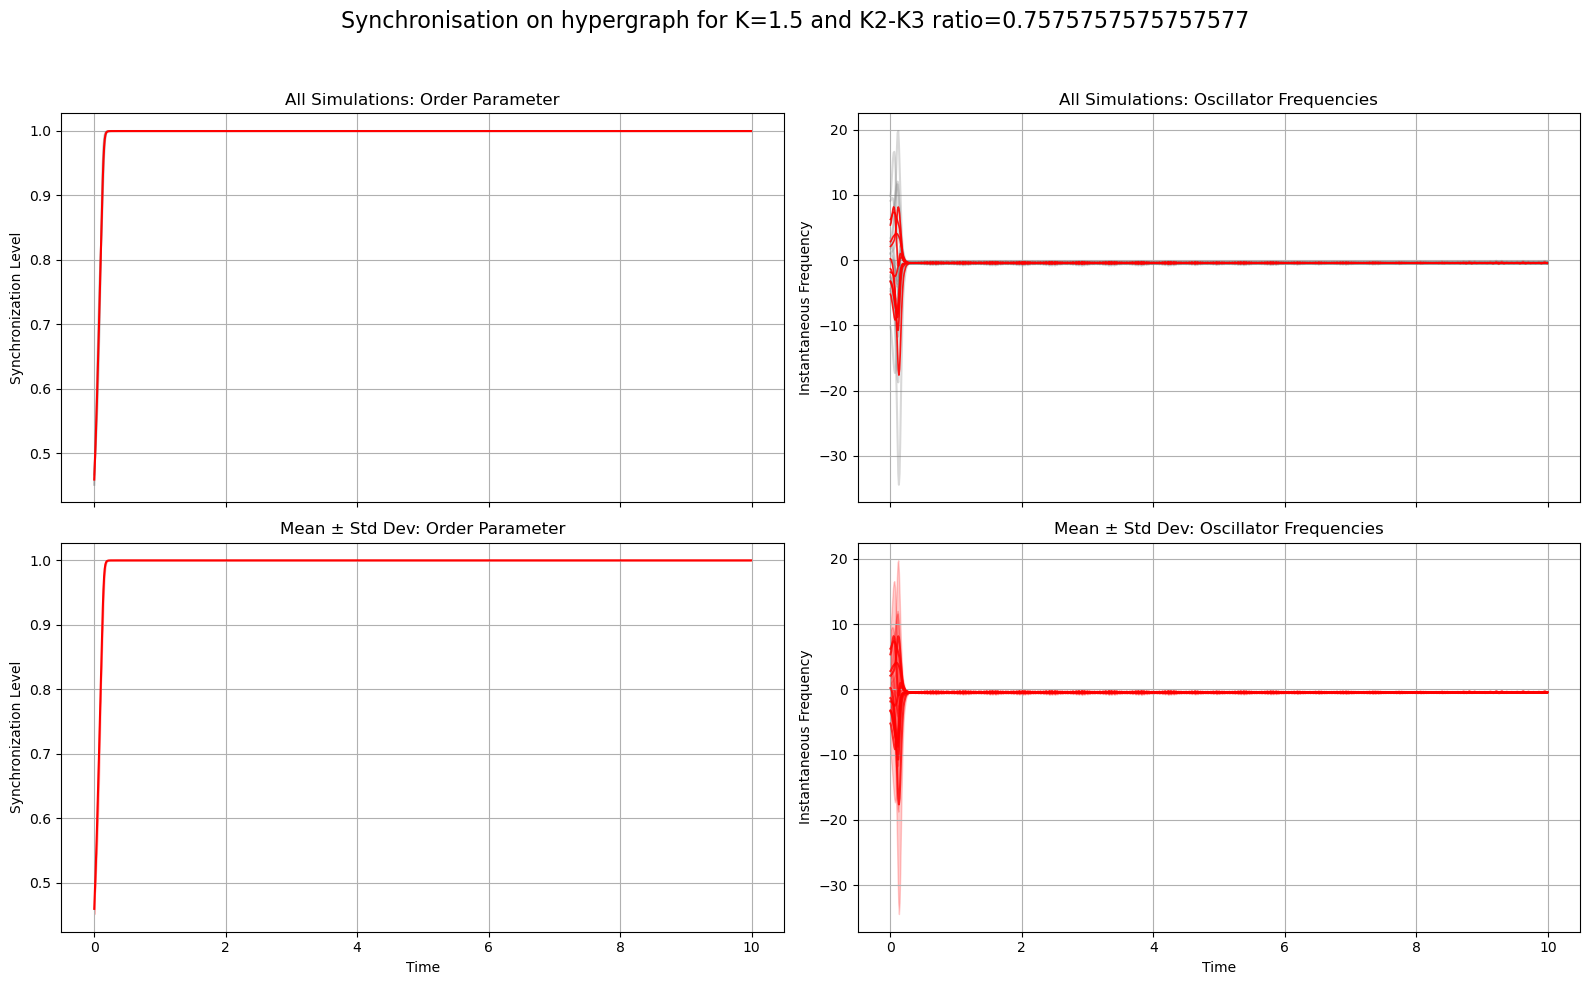

In [110]:
t_eval, r_all, freq_dfs = simulate_xgi_time_series(N, K, K2K3_ratio, T, dt, n_sim)
plot_synchronisation(t_eval, r_all, freq_dfs)

Explore order parameter phase transition

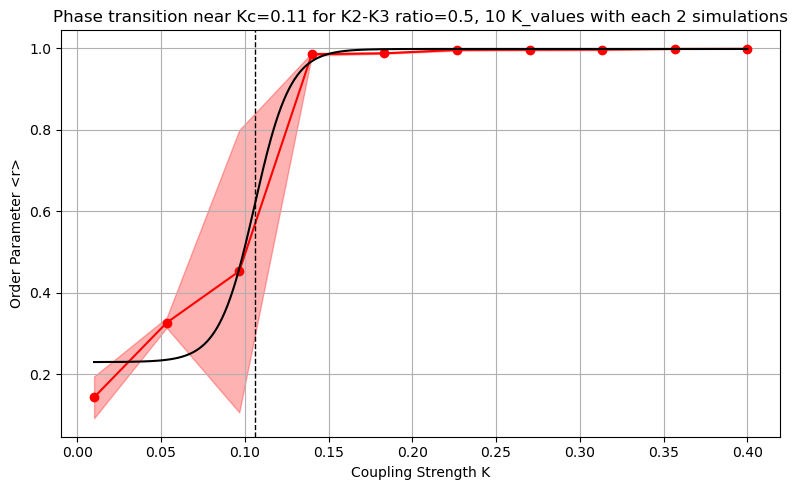

In [ ]:
K_values=np.linspace(0.01, 0.4, 100)
r_avg_values, r_std_values, Kc_estimation_list = compute_order_parameter_values(N, K, K2K3_ratio, T, dt, n_sim, K_values)
plot_phase_transition(K_values, r_avg_values, r_std_values, Kc_estimation_list)

Explore critical value against high-orderness

In [ ]:
Kc_data = []

for K2K3_ratio in np.linspace(0, 1, 100):
    K_values = np.linspace(0.01, 0.4, 10)
    r_avg_values, r_std_values, Kc_estimation_list = compute_order_parameter_values(N, K, K2K3_ratio, T, dt, n_sim, K_values)

    valid_Kcs = [Kc for Kc in Kc_estimation_list if Kc is not None]
    if len(valid_Kcs) == 0:
        raise ValueError("No valid Kc estimations were found.")
    Kc_mean = np.mean(valid_Kcs)
    Kc_std  = np.std(valid_Kcs)
    Kc_data.append([K2K3_ratio, Kc_mean, Kc_std])

plot_K2K3_ratio(Kc_data)

Explore behaviour of multivariate information metrics

In [254]:
from sklearn.utils import Bunch
import infotopo_no_prints
import numpy as np
import os
from collections import defaultdict
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [242]:
# Old functions (can be removed if all works accordingly AND I dont want to plot individually)
def plot_simulation_stats(avg_array, length_arrays):
    num_timesteps = avg_array.shape[0]
    x = np.arange(num_timesteps)  # Timestep indices

    # Set up figure with 2 vertically stacked subplots
    fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(8, 8), sharex=True)

    # Helper to plot mean + std fill
    def plot_with_std(ax, data, label, color):
        means = data[:, 0]
        stds = data[:, 1]
        ax.plot(x, means, label=label, color=color)
        ax.fill_between(x, means - stds, means + stds, color=color, alpha=0.2)

    # --- Top subplot: All keys ---
    plot_with_std(ax1, avg_array, "All orders", "black")
    ax1.set_title("All Orders - Mean and Std Over Time")
    ax1.set_ylabel("MI")
    ax1.legend(loc="upper left")
    ax1.grid(True)

    # --- Bottom subplot: Key lengths ---
    color_map = plt.cm.get_cmap("tab10")
    sorted_lengths = sorted(length_arrays.keys())

    for idx, length in enumerate(sorted_lengths):
        label = f"Order-{length}"
        color = color_map(idx % 10)
        plot_with_std(ax2, length_arrays[length], label, color)

    ax2.set_title("Order Interaction Groups - Mean and Std Over Time")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("MI")
    ax2.legend(loc="upper left")
    ax2.grid(True)

    fig.tight_layout()
    plt.show()

def plot_information_landscape(simulation_result, keys_list, orders_list):
    # Define data directly as a list of lists
    data = []

    for TC_dictionary in simulation_result['TC_lists']:
        # TC_dictionary = ast.literal_eval(TC_dictionary)
        sorted_dict = dict(sorted(TC_dictionary.items(), key=lambda item: (len(item[0]), item[1])))
        data.append(list(sorted_dict.values()))

    # Convert to NumPy array
    data = np.array(data)

    # Keep only the first part
    data = data[:]

    # Define time and order indices
    x = np.arange(data.shape[0])  # Time steps
    y = np.arange(data.shape[1])  # Order indices
    X, Y = np.meshgrid(x, y, indexing="xy")  # Corrected meshgrid orientation
    Z = data.T  # Transpose to align with heatmap orientation

    # Create figure with two subplots (side-by-side)
    fig = plt.figure(figsize=(14, 6))

    ### First Plot (Heatmap) ###
    ax1 = fig.add_subplot(1, 2, 1)  # First subplot

    cax = ax1.imshow(data.T, aspect='auto', cmap='viridis', origin='lower')

    # Remove colorbar for first plot
    # cbar1 = fig.colorbar(cax, ax=ax1, label="Significance")  # <- This line is removed

    # Set x-axis (time)
    ax1.set_xlabel("Time")
    ax1.set_xticks(np.linspace(0, data.shape[0] - 1, 6))
    ax1.set_xticklabels(np.linspace(0, data.shape[0] - 1, 6, dtype=int))

    # Set y-axis (order)
    ax1.set_ylabel("Order")
    ax1.set_yticks(orders_list)
    ax1.set_yticklabels(keys_list)
    ax1.set_title("Heatmap: Normalised Order Significance")

    ax1.invert_yaxis()  # Invert y-axis direction

    ### Second Plot (3D Surface) ###
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')  # Second subplot

    # Set the view angle
    ax2.view_init(elev=40, azim=-110)

    # Create surface plot
    surf = ax2.plot_surface(X, Y, Z, cmap='viridis')

    # Add colorbar only to the second plot
    cbar2 = fig.colorbar(surf, ax=ax2, shrink=0.6, aspect=10, pad=0.1, label="Significance")

    # Remove numbers from the colorbar
    cbar2.set_ticks([])  # This removes the tick marks
    cbar2.ax.set_yticklabels([])  # This removes the tick labels

    # Set y-axis ticks and labels
    ax2.set_yticks(orders_list)
    ax2.set_yticklabels(keys_list)
    ax2.invert_yaxis()  # **Ensure y-axis matches heatmap**

    # Labels
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Order")
    ax2.set_zticks([])  # Remove z-axis ticks
    ax2.set_title("3D Surface: Normalised Order Significance")

    # Adjust layout for better spacing
    plt.suptitle(f'Kuramoto_N={N}_K1={K}_K2={K}_T={T}')
    plt.tight_layout()

    # Save the figure
    # save_dir = r"C:\Users\cyril\Documents\Study\PhD\Logbook\2025\Week 36 (23-06)"
    # os.makedirs(save_dir, exist_ok=True)
    # filename = f"Kuramoto_N{N}_K1_{K}_K2_{K}_T_{T}.png"
    # save_path = os.path.join(save_dir, filename)
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


In [261]:
# Optimized function to compute TSE complexity
def compute_tse_complexity(TC_dict):
    """
    Computes the TSE complexity given a dictionary of total correlations.
    
    Parameters:
        TC_dict (dict): Dictionary of total correlations where keys are tuples (subsets).
        
    Returns:
        float: The TSE complexity.
    """
    N = max(len(subset) for subset in TC_dict)  # Maximum subset size
    TSE = 0
    for gamma in range(1, N):
        TC_full = (gamma / N) * TC_dict[tuple(range(1, N + 1))]
        E_TC_gamma = np.mean([TC_dict[subset] for subset in TC_dict if len(subset) == gamma])
        TSE += TC_full - E_TC_gamma
    return TSE

# Convert pandas dataframe to bunch object
def dataframe_to_bunch(dataframe, target=None, feature_names=None, target_names=None, descr="Custom dataset"):
    if feature_names is None:
        feature_names = dataframe.columns.tolist()
    
    return Bunch(
        data=dataframe.to_numpy(),
        target=target if target is not None else np.zeros(dataframe.shape[0]),
        feature_names=feature_names,
        target_names=target_names if target_names is not None else ["target"],
        DESCR=descr
    )

# Obtain topological information metrics using infotopo
def obtain_infotopo_metrics(dataset, dimension_max=0, dimension_tot=0):

    if dimension_max == 0:
        dimension_max = 3 #dataset.shape[1]
    if dimension_tot == 0:
        dimension_tot = 9 #dataset.shape[1]
    
    sample_size = dataset.shape[0]
    nb_of_values = 16
    forward_computation_mode = True
    work_on_transpose = False
    supervised_mode = False
    sampling_mode = 1
    deformed_probability_mode = False

    information_topo = infotopo_no_prints.infotopo(dimension_max = dimension_max,
                                dimension_tot = dimension_tot,
                                sample_size = sample_size,
                                work_on_transpose = work_on_transpose,
                                nb_of_values = nb_of_values,
                                sampling_mode = sampling_mode,
                                deformed_probability_mode = deformed_probability_mode,
                                supervised_mode = supervised_mode,
                                forward_computation_mode = forward_computation_mode)
    
    Nentropie = information_topo.simplicial_entropies_decomposition(dataset)
    Ninfomut = information_topo.simplicial_infomut_decomposition(Nentropie)
    Nfree_energy = information_topo.total_correlation_simplicial_lanscape(Nentropie)
    
    return  Nentropie, Ninfomut, Nfree_energy

# Function to compute metrics for a time window sliding over a given timeseries
def interactions_values_relative(df_input, window_size=0, window_step=0, dimension_max=0, dimension_tot=0):
    # Initialize an empty DataFrame
    columns = ['R_sum', 'S_sum', 'TSE_value', 'R_std', 'S_std', 'TC_lists']
    df_output = pd.DataFrame(columns=columns)

    # Set initial window conditions
    if window_size == 0:
        window_size = len(df_input)-1
    if window_step == 0:
        window_step = 1
    window_start = 0
    window_end = window_start + window_size

    while window_end < len(df_input):
        bunch_data = dataframe_to_bunch(df_input.iloc[window_start:window_end])
        Nentropie, Ninfomut, Nfree_energy = obtain_infotopo_metrics(bunch_data.data, dimension_max, dimension_tot)

        S_values = [(TC - MI) / 2 for TC, MI in zip(Nfree_energy.values(), Ninfomut.values())]
        R_values = [(TC + MI) / 2 for TC, MI in zip(Nfree_energy.values(), Ninfomut.values())]
        S_std = np.std(S_values, ddof=1)
        R_std = np.std(R_values, ddof=1)
        S_sum = sum(S_values)
        R_sum = sum(R_values)
        TSE_value = compute_tse_complexity(Nfree_energy)

        # Add the new values to the dataframe
        new_row = pd.DataFrame({'R_sum': [R_sum], 'S_sum': [S_sum], 'TSE_value': [TSE_value], 'R_std': [R_std], 'S_std':[S_std], 'TC_lists':[Ninfomut]})
        df_output = pd.concat([df_output, new_row], ignore_index=True)
        
        window_start += window_step
        window_end += window_step

    # Normalize all the values so that the S and R values are all positive and the maximum R and S are 1 and minimum 0.
    min_R = df_output.iloc[:, 0].min()
    df_output.iloc[:, 0] += abs(min_R)

    df_output['S_sum'] = (df_output['S_sum'] - df_output['S_sum'].min()) / (df_output['S_sum'].max() - df_output['S_sum'].min())
    df_output['R_sum'] = (df_output['R_sum'] - df_output['R_sum'].min()) / (df_output['R_sum'].max() - df_output['R_sum'].min())

    return df_output

def obtain_order_labels(data):
    # Count occurrences of each key length
    length_counts = {}

    for key in data.keys():
        length = len(key)  # Get length of the tuple (key)
        length_counts[length] = length_counts.get(length, 0) + 1

    # Initialize variables
    cumulative_sum = -0.5
    orders_list = []

    # Iterate through dictionary values and compute cumulative sums
    for value in length_counts.values():
        cumulative_sum += value  # Add current value to the cumulative sum
        orders_list.append(cumulative_sum)  # Store the cumulative sum

    # Convert keys to strings and store in a list
    keys_list = [str(key) for key in length_counts.keys()]

    return keys_list, orders_list

def analyze_simulation_results(simulation_results):
    num_timesteps = len(simulation_results[0])
    
    avg_per_timestep = []  # (mean, std) across all keys
    length_stats_dict = defaultdict(list)  # key = length, value = list of (mean, std) per timestep

    for t_idx in range(num_timesteps):
        values_per_key = defaultdict(list)

        # Gather values from all simulations at timestep t_idx
        for sim_df in simulation_results:
            d = sim_df.loc[t_idx, 'TC_lists']
            for k, v in d.items():
                values_per_key[k].append(v)

        # Compute mean and std of all values
        all_values = [v for values in values_per_key.values() for v in values]
        avg_per_timestep.append((np.mean(all_values), np.std(all_values)))

        # Group by key length dynamically
        length_to_values = defaultdict(list)
        for k, vals in values_per_key.items():
            length_to_values[len(k)].extend(vals)

        # Compute mean and std per length
        for length, vals in length_to_values.items():
            length_stats_dict[length].append((np.mean(vals), np.std(vals)))

    # Convert to arrays
    avg_array = np.array(avg_per_timestep)
    length_arrays = {length: np.array(stats) for length, stats in length_stats_dict.items()}

    return avg_array, length_arrays

def compute_average_dataframe(simulation_results):
    num_timesteps = len(simulation_results[0])

    averaged_dicts = []

    for t_idx in range(num_timesteps):
        aggregated_values = defaultdict(list)

        # Collect values from all simulations at the current timestep
        for sim_df in simulation_results:
            d = sim_df.loc[t_idx, 'TC_lists']
            for k, v in d.items():
                aggregated_values[k].append(v)

        # Compute mean per key
        averaged_dict = {k: sum(vs) / len(vs) for k, vs in aggregated_values.items()}
        averaged_dicts.append(averaged_dict)

    # Create average dataframe using index only (no 'time' column)
    df_average = pd.DataFrame({'TC_lists': averaged_dicts})

    return df_average

def combined_simulation_plot(simulation_results, N, K, K2K3_ratio, T, dt, n_sim):
    # --- Part 1: Data for first two plots ---
    avg_array, length_arrays = analyze_simulation_results(simulation_results)
    num_timesteps = avg_array.shape[0]
    x = np.arange(num_timesteps)  # Timestep indices

    # --- Part 2: Data for heatmap and 3D surface ---
    simulation_result_average = compute_average_dataframe(simulation_results)
    # Just take first TC_lists entry to extract keys and orders for labeling
    keys_list, orders_list = obtain_order_labels(simulation_result_average["TC_lists"][0])

    # Prepare data for heatmap and surface plot
    data = []
    for TC_dictionary in simulation_result_average['TC_lists']:
        sorted_dict = dict(sorted(TC_dictionary.items(), key=lambda item: (len(item[0]), item[1])))
        data.append(list(sorted_dict.values()))
    data = np.array(data)

    x_surf = np.arange(data.shape[0])  # Time steps
    y_surf = np.arange(data.shape[1])  # Order indices
    X, Y = np.meshgrid(x_surf, y_surf, indexing="xy")
    Z = data.T

    # Set up figure with 2 rows and 2 columns
    fig = plt.figure(figsize=(14, 10))

    # Helper function for mean + std fill plot
    def plot_with_std(ax, data, label, color):
        means = data[:, 0]
        stds = data[:, 1]
        ax.plot(x, means, label=label, color=color)
        ax.fill_between(x, means - stds, means + stds, color=color, alpha=0.2)

    # --- Plot 1: All orders mean and std (top left) ---
    ax1 = fig.add_subplot(2, 2, 1)
    plot_with_std(ax1, avg_array, "All orders", "black")
    ax1.set_title("All Orders - Mean and Std Over Time")
    ax1.set_ylabel("MI")
    ax1.legend(loc="upper left")
    ax1.grid(True)

    # --- Plot 2: Key lengths mean and std (bottom left) ---
    ax2 = fig.add_subplot(2, 2, 3, sharex=ax1)
    color_map = plt.cm.get_cmap("tab10")
    sorted_lengths = sorted(length_arrays.keys())

    for idx, length in enumerate(sorted_lengths):
        label = f"Order-{length}"
        color = color_map(idx % 10)
        plot_with_std(ax2, length_arrays[length], label, color)

    ax2.set_title("Order Interaction Groups - Mean and Std Over Time")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("MI")
    ax2.legend(loc="upper left")
    ax2.grid(True)

    # --- Plot 3: Heatmap (top right) ---
    ax3 = fig.add_subplot(2, 2, 2)
    cax = ax3.imshow(data.T, aspect='auto', cmap='viridis', origin='lower')
    ax3.set_xlabel("Time")
    ax3.set_xticks(np.linspace(0, data.shape[0] - 1, 6))
    ax3.set_xticklabels(np.linspace(0, data.shape[0] - 1, 6, dtype=int))
    ax3.set_ylabel("Order")
    ax3.set_yticks(orders_list)
    ax3.set_yticklabels(keys_list)
    ax3.set_title("Heatmap: Normalised Order Significance")
    ax3.invert_yaxis()

    # --- Plot 4: 3D surface (bottom right) ---
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    ax4.view_init(elev=40, azim=-110)
    surf = ax4.plot_surface(X, Y, Z, cmap='viridis')
    cbar = fig.colorbar(surf, ax=ax4, shrink=0.6, aspect=10, pad=0.1, label="Significance")
    cbar.set_ticks([])
    cbar.ax.set_yticklabels([])

    ax4.set_yticks(orders_list)
    ax4.set_yticklabels(keys_list)
    ax4.invert_yaxis()
    ax4.set_xlabel("Time")
    ax4.set_ylabel("Order")
    ax4.set_zticks([])
    ax4.set_title("3D Surface: Normalised Order Significance")

    if N is not None and K is not None and T is not None:
        plt.suptitle(f'Kuramoto_N={N}_K={K}_K2K3ratio={K2K3_ratio}_T={T}_dt={dt}_nsim={n_sim}', fontsize=16)

    # Save the file in directory
    save_dir = r"C:\Users\cyril\Documents\Study\PhD\Logbook\2025\Week 36 (23-06)"
    os.makedirs(save_dir, exist_ok=True)
    filename = f"Kuramoto_N={N}_K={K}_K2K3ratio={K2K3_ratio}_T={T}_dt={dt}_nsim={n_sim}.png"
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
    plt.show()


C:\Users\cyril\AppData\Local\Temp\ipykernel_845336\1480298887.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output = pd.concat([df_output, new_row], ignore_index=True)
C:\Users\cyril\AppData\Local\Temp\ipykernel_845336\1480298887.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output = pd.concat([df_output, new_row], ignore_index=True)
C:\Users\cyril\AppData\Local\Temp\ipykernel_845336\1480298887.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA

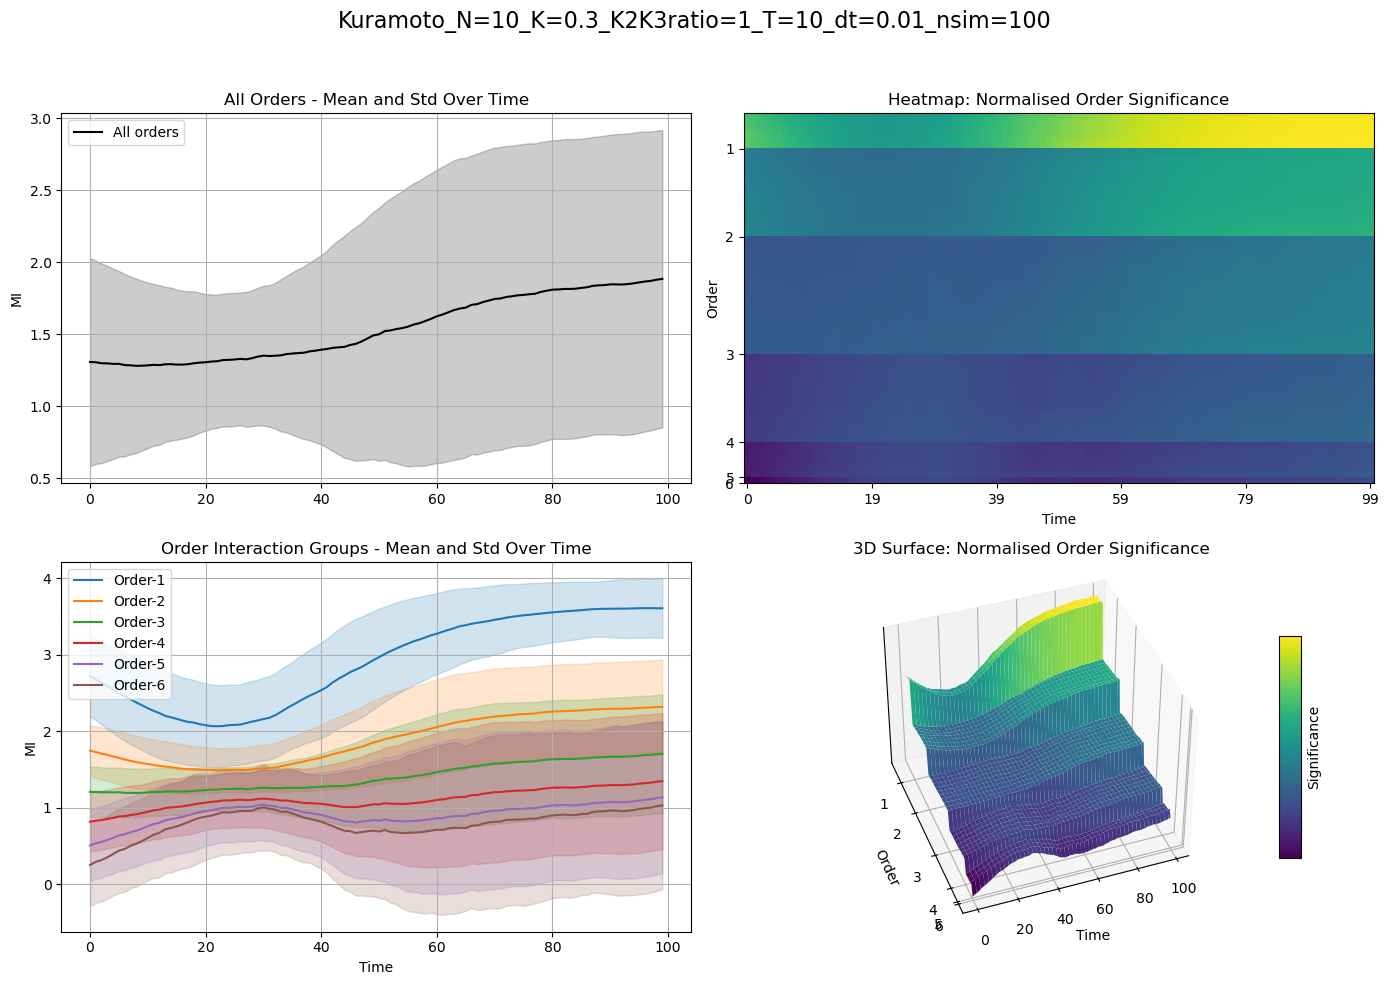

In [263]:
# System settings
N = 10
K = 0.3
K2K3_ratio = 1
T = 10 
dt = 0.01
n_sim = 100

# Run simulations
simulation_results = []
frequencies_dfs = simulate_xgi_time_series(N, K, K2K3_ratio, T, dt, n_sim)[2]

# Obtain information metrics
window_size = 400
window_step = 6
dimension_max = 6
dimension_tot = 6

for frequency_dataframe in frequencies_dfs:
    df_oscillators = interactions_values_relative(frequency_dataframe, window_size, window_step, dimension_max, dimension_tot)
    simulation_results.append(df_oscillators)

combined_simulation_plot(simulation_results, N, K, K2K3_ratio, T, dt, n_sim)